# Часть 1б: BERTopic

Ноутбук для финального подбора BERTopic, сравнения RuBERT/GigaEmbeds и вывода топ-слов выбранных моделей.

## 0. Подготовка среды

In [3]:
#фикс совместимости
import inspect
from collections import namedtuple

if not hasattr(inspect, "getargspec"):
    ArgSpec = namedtuple("ArgSpec", "args varargs keywords defaults")
    def getargspec(func):
        fs = inspect.getfullargspec(func)
        return ArgSpec(fs.args, fs.varargs, fs.varkw, fs.defaults)
    inspect.getargspec = getargspec

In [4]:
#зависимости для bertopic
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "einops", "transformers<5", "sentence-transformers<5"])

0

In [5]:
#импорты
import re
import string
import os

os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import gc
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    pd.set_option("future.infer_string", False)
except Exception:
    pass

try:
    pd.options.mode.string_storage = "python"
except Exception:
    pass

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from joblib import Parallel, delayed
from tqdm.auto import tqdm
tqdm.pandas()

from stop_words import get_stop_words
from wordcloud import WordCloud
from pymorphy3 import MorphAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

from gensim import corpora, models
from gensim.models.phrases import Phrases, Phraser
from gensim.models import CoherenceModel
from gensim.corpora import MmCorpus

from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.sparse import csr_matrix

import umap
from umap import UMAP

import torch
from transformers import pipeline, set_seed

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer
from sentence_transformers import SentenceTransformer
import hdbscan

import networkx as nx

DEVICE = "cpu"

print("Все библиотеки загружены.")
print(f"PyTorch device: {DEVICE}")

Все библиотеки загружены.
PyTorch device: cpu


In [6]:
#настройки
DATA_DIR = "."
FILE_PART1 = os.path.join(DATA_DIR, "output_cursovaya_part1.xlsx")
FILE_PART2 = os.path.join(DATA_DIR, "output_cursovaya_part2.xlsx")

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EMB_CACHE_DIR = OUTPUT_DIR / "emb_cache"
EMB_CACHE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

TUNE_SAMPLE = 15_000
TRAIN_SAMPLE = 100_000

PREPROCESS_N_JOBS = 1
EMBED_N_WORKERS = 1
EMBED_DOC_CHUNK = 2_000
REVIEW_TOP_MODELS = 3
REVIEW_TOP_GIGA = 2
REVIEW_USE_KEYBERT = False
DO_REVIEW_R15 = False
DO_REVIEW_R20 = True

EMB_CACHE_TAG = "v2_giga_cluster_longctx"

EMBEDDING_CANDIDATES = {
    "rubert_sentence": {
        "model_name": "DeepPavlov/rubert-base-cased-sentence",
        "batch_size": 64,
        "max_seq_length": 256,
        "encode_kwargs": {"normalize_embeddings": True},
    },
    "giga_instruct": {
        "model_name": "ai-sage/Giga-Embeddings-instruct",
        "batch_size": 16,
        "max_seq_length": 1024,
        "trust_remote_code": True,
        "encode_kwargs": {
            "normalize_embeddings": True,
            "prompt": "Instruct: Определи основную тему и подтему телеграм-поста для тематической кластеризации\nQuery: ",
        },
    },
}

EMBEDDING_MODEL_NAME = EMBEDDING_CANDIDATES["rubert_sentence"]["model_name"]

print(f"Данные: {FILE_PART1}, {FILE_PART2}")
print(f"Результаты: {OUTPUT_DIR}/")
print(f"Seed: {SEED}")
print(f"DEVICE: {DEVICE}")
print(f"PREPROCESS_N_JOBS: {PREPROCESS_N_JOBS}")
print(f"EMBED_N_WORKERS: {EMBED_N_WORKERS}")
print(f"EMBED_DOC_CHUNK: {EMBED_DOC_CHUNK}")
print(f"EMB_CACHE_TAG: {EMB_CACHE_TAG}")
print(f"REVIEW_TOP_GIGA: {REVIEW_TOP_GIGA}")
print(f"DO_REVIEW_R15: {DO_REVIEW_R15}")
print(f"DO_REVIEW_R20: {DO_REVIEW_R20}")


Данные: .\output_cursovaya_part1.xlsx, .\output_cursovaya_part2.xlsx
Результаты: results/
Seed: 42
DEVICE: cpu
PREPROCESS_N_JOBS: 1
EMBED_N_WORKERS: 1
EMBED_DOC_CHUNK: 2000
EMB_CACHE_TAG: v2_giga_cluster_longctx
REVIEW_TOP_GIGA: 2
DO_REVIEW_R15: False
DO_REVIEW_R20: True


## 1. Загрузка и предобработка данных

In [7]:
#загрузка данных
def get_usecols(xlsx_path):
    cols = pd.read_excel(xlsx_path, nrows=0, engine="openpyxl").columns.tolist()
    needed = ["post_id", "message_id", "date", "channel_ref", "channel", "text"]
    return [c for c in needed if c in cols]

usecols_part1 = get_usecols(FILE_PART1)
usecols_part2 = get_usecols(FILE_PART2)
usecols = sorted(list(set(usecols_part1) | set(usecols_part2)))

df1 = pd.read_excel(FILE_PART1, usecols=usecols, engine="openpyxl")
df2 = pd.read_excel(FILE_PART2, usecols=usecols, engine="openpyxl")

df = pd.concat([df1, df2], ignore_index=True).drop_duplicates().reset_index(drop=True)
print(df.shape)
display(df.head())

(1093965, 4)


,channel,message_id,date,text
0,@RKadyrov_95,4361,2024-01-15 07:00:13+00:00,Сегодня рано утром сотрудники МВД России по Ше...
1,@RKadyrov_95,4362,2024-01-15 09:16:26+00:00,"Беспомощная ситуация жителей сектора Газа, кот..."
2,@RKadyrov_95,4363,2024-01-15 14:34:46+00:00,И снова группа «Аида» спецназа «АХМАТ» в работ...
3,@RKadyrov_95,4364,2024-01-16 08:25:50+00:00,Друзья! Сегодня многочисленные поздравления с ...
4,@RKadyrov_95,4365,2024-01-16 19:23:46+00:00,"Друзья! Проект, подготовленный и реализованный..."


In [8]:
#базовая очистка
def _series_to_pylist_safe(s):
    arr = getattr(getattr(s, "array", None), "_pa_array", None)
    if arr is not None:
        values = []
        for chunk in arr.iterchunks():
            values.extend(chunk.to_pylist())
        return values
    return list(s)

raw_text_values = _series_to_pylist_safe(df["text"])

keep_idx = []
text_values = []

for i, x in enumerate(raw_text_values):
    if x is None or pd.isna(x):
        continue
    x = str(x)
    if x.strip() == "":
        continue
    keep_idx.append(i)
    text_values.append(x)

df = df.iloc[keep_idx].copy().reset_index(drop=True)
df["text"] = pd.Series(np.asarray(text_values, dtype=object), dtype=object)

if "channel_ref" not in df.columns:
    if "channel" in df.columns:
        raw_channel_values = _series_to_pylist_safe(df["channel"])
        channel_values = [str(x) if x is not None and not pd.isna(x) else "unknown_channel" for x in raw_channel_values]
    else:
        channel_values = ["unknown_channel"] * len(df)
else:
    raw_channel_values = _series_to_pylist_safe(df["channel_ref"])
    channel_values = [str(x) if x is not None and not pd.isna(x) else "unknown_channel" for x in raw_channel_values]

df["channel_ref"] = pd.Series(np.asarray(channel_values, dtype=object), dtype=object)
df["channel_ref"] = df["channel_ref"].astype("category")

def _normalize_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

df["text_raw"] = pd.Series(np.asarray([_normalize_spaces(x) for x in text_values], dtype=object), dtype=object)
df = df.reset_index(drop=True)
df["doc_id"] = np.arange(len(df), dtype=np.int64)

print(df[["doc_id", "channel_ref", "date", "text_raw"]].head())


   doc_id   channel_ref                       date  \
0       0  @RKadyrov_95  2024-01-15 07:00:13+00:00   
1       1  @RKadyrov_95  2024-01-15 09:16:26+00:00   
2       2  @RKadyrov_95  2024-01-15 14:34:46+00:00   
3       3  @RKadyrov_95  2024-01-16 08:25:50+00:00   
4       4  @RKadyrov_95  2024-01-16 19:23:46+00:00   

                                            text_raw  
0  Сегодня рано утром сотрудники МВД России по Ше...  
1  Беспомощная ситуация жителей сектора Газа, кот...  
2  И снова группа «Аида» спецназа «АХМАТ» в работ...  
3  Друзья! Сегодня многочисленные поздравления с ...  
4  Друзья! Проект, подготовленный и реализованный...  


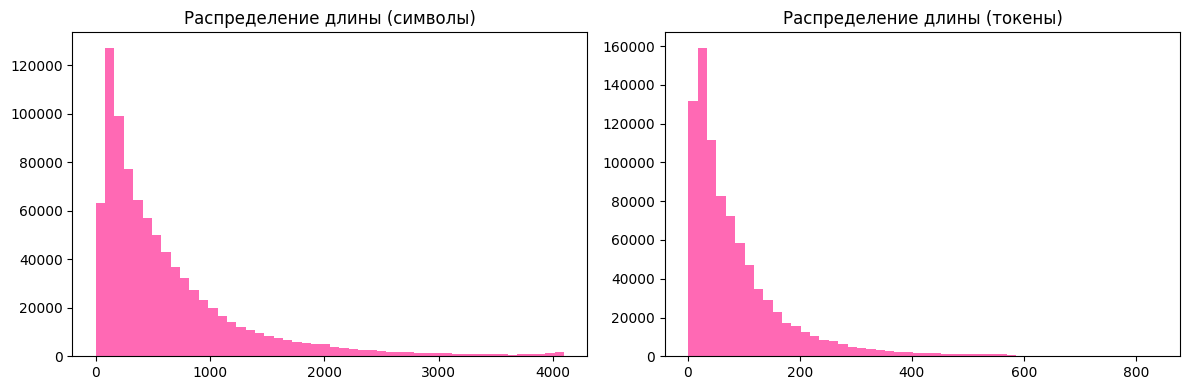

In [9]:
#распределение длины текстов
text_raw_values = list(df["text_raw"])
df["len_chars"] = pd.Series(np.asarray([len(x) for x in text_raw_values], dtype=np.int32), dtype=np.int32)
df["len_tokens_raw"] = pd.Series(np.asarray([len(x.split()) for x in text_raw_values], dtype=np.int32), dtype=np.int32)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["len_chars"], bins=50, color="hotpink")
axes[0].set_title("Распределение длины (символы)")
axes[1].hist(df["len_tokens_raw"], bins=50, color="hotpink")
axes[1].set_title("Распределение длины (токены)")
plt.tight_layout()
plt.show()


## 2. Лемматизация и очистка текста

In [10]:
#стоп-слова и очистка
stop_ru = set(get_stop_words("russian"))
stop_en = set(get_stop_words("english"))

custom_stop = {
    "канал", "канале", "каналу", "каналом", "каналы",
    "подписаться", "подписка", "подписывайтесь", "подпишись", "подпишитесь",
    "telegram", "телеграм", "телеграмм",
    "смотреть", "смотрите", "посмотреть",
    "читать", "читайте",
    "новость", "новости",
    "видео", "эфир", "эфире", "стрим", "трансляция", "live",
    "репост", "переслать", "поделиться",
    "rutube", "рутуб", "пул", "max",
}

topic_noise_stop = {
    "заявить", "сообщить", "сказать", "который", "очень", "вообще", "никто", "никакой",
    "сегодня", "вчера", "завтра", "просто", "это", "весь", "ещё", "также",
    "будьте", "находитесь", "улице", "помещениях", "окон",

    "детей", "дети", "ребенка", "ребёнка", "человека", "человек", "людей", "люди",
    "возможности", "возможность", "условиях", "условия", "условии",
    "например", "рассказал", "рассказала", "стало", "данные", "нового", "новый",
    "работы", "работа", "средств", "средства", "движения", "движение",
    "рост", "частных", "центра", "округе", "районах", "районах населенных",
    "некоторых", "основное", "временно", "объединений", "проживающих", "гражданства",
    "ситуацию", "ситуация", "версия", "ответить", "встреча", "рассказать",

    "instagram", "youtube", "whatsapp", "google", "meta", "vpn", "wifi",
    "cnn", "reuters", "bloomberg", "fox", "telegraph", "wsj", "nyt", "abc", "newsweek",
    "politico", "journal", "times", "post", "social", "digital", "business", "national",
    "axios", "arabiya", "unherd", "pais", "bild", "oracle", "apple", "tesla",
    "svt", "lrt", "dpa", "corp", "online", "week", "report", "data", "info",

    "tmervvoenkor", "rua", "engblueskywhatsapp", "xix", "shot", "baza", "upd", "zergulio",
    "boosty", "sponsr", "metametrica", "izru", "mash", "mashru", "ura", "rtvi", "вчк-огпу",

    "бпла", "всу", "сво", "рф", "сша", "ес", "оон", "мвд", "фбр", "мтс",
    "млн", "млрд", "трлн", "руб", "рублей", "долларов", "доллара", "евро",
    "года", "году", "лет", "год", "месяц", "день", "дней",

    "области", "область", "районе", "район", "городе", "города", "страны", "страна",
    "территории", "территорией", "территория", "окрестности", "округе",
    "взрыв", "взрывы", "поражены", "восстановлено", "боевых", "боевые",
    "серия", "анализ", "построили", "должность", "производства", "освобождение",
    "подразделений", "подразделения", "компаний", "российского", "специальной",
    "специальной военной", "военной", "народной", "населенных", "населенных пунктов",

    "герань", "герани", "гербера", "герберы", "умпк", "fpv", "отрк", "himars",
    "atacms", "storm", "shadow", "patriot", "nasams", "thaad", "tomahawk",
    "баба", "яга", "баба-яга", "патч", "патч-антенна",

    "проверяйте", "убедитесь", "ориентировочно", "номер", "класс",
    "девочка", "животных", "наушники", "авокадо", "роботы", "деревьев", "доски",
    "мафия", "коррупция", "мусора", "красная", "тихий", "горя", "плохие",
}

stopwords_all = stop_ru | stop_en | custom_stop
vectorizer_stopwords = stopwords_all | topic_noise_stop

punct = set(string.punctuation + '\u00ab\u00bb\u2014\u2026\u201c\u201d\u0060\u2018\u2019\u2013')
morph = MorphAnalyzer(lang="ru")

def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", " ", text)
    text = re.sub(r"[^a-zа-яё\d\s-]", " ", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stopwords_all and t not in punct and len(t) > 2 and not t.isdigit()]
    lemmas = [morph.parse(t)[0].normal_form for t in tokens]
    return " ".join(lemmas)

def preprocess_text_bert(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|@\S+|#\S+", " ", text)
    text = re.sub(r"\bподпиш(?:ись|итесь|ись)\b", " ", text)
    text = re.sub(r"\btelegram\b|\bтелеграм(?:м)?\b|\brutube\b|\bрутуб\b", " ", text)
    text = re.sub(r"\b(?:instagram|youtube|whatsapp|google|meta|vpn|wifi|cnn|reuters|bloomberg|fox|telegraph|wsj|nyt|abc|newsweek|politico)\b", " ", text)
    text = re.sub(r"\b(?:tmervvoenkor|rua|engblueskywhatsapp|xix|shot|baza|upd|zergulio|boosty|sponsr|metametrica|izru|mash)\b", " ", text)
    text = re.sub(r"\b(?:млн|млрд|трлн|руб|рублей|долларов|доллара|евро|бпла|всу|сво|рф|сша|ес|оон)\b", " ", text)
    text = re.sub(r"\b[a-z]{1,4}\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Функции предобработки готовы.")

Функции предобработки готовы.


In [11]:
#предобработка корпуса
PREPROCESS_N_JOBS = 1

def parallel_apply(series, func, n_jobs=1):
    values = list(series)
    return pd.Series(
        np.asarray([func(x) for x in tqdm(values)], dtype=object),
        index=series.index,
        dtype=object,
    )

def preprocess_text_embed(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\S+|#\S+", " ", text)
    text = re.sub(r"\bподпиш(?:ись|итесь|ись)\b", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_clean"] = parallel_apply(df["text_raw"], preprocess_text, n_jobs=PREPROCESS_N_JOBS)
df["text_clean_bert"] = parallel_apply(df["text_raw"], preprocess_text_bert, n_jobs=PREPROCESS_N_JOBS)
df["text_embed"] = parallel_apply(df["text_raw"], preprocess_text_embed, n_jobs=PREPROCESS_N_JOBS)

df["len_tokens_clean"] = pd.Series(
    np.asarray([len(x.split()) for x in df["text_clean"]], dtype=np.int32),
    dtype=np.int32,
)
df["len_tokens_clean_bert"] = pd.Series(
    np.asarray([len(x.split()) for x in df["text_clean_bert"]], dtype=np.int32),
    dtype=np.int32,
)
df["len_tokens_embed"] = pd.Series(
    np.asarray([len(x.split()) for x in df["text_embed"]], dtype=np.int32),
    dtype=np.int32,
)

before = len(df)
df = df[
    (df["len_tokens_clean"] > 3)
    & (df["len_tokens_clean_bert"] > 3)
    & (df["len_tokens_embed"] > 3)
].reset_index(drop=True)

print(f"Документов после фильтрации: {len(df):,} (убрано {before - len(df):,} коротких)")

  0%|          | 0/866129 [00:00<?, ?it/s]

  0%|          | 0/866129 [00:00<?, ?it/s]

  0%|          | 0/866129 [00:00<?, ?it/s]

Документов после фильтрации: 847,684 (убрано 18,445 коротких)


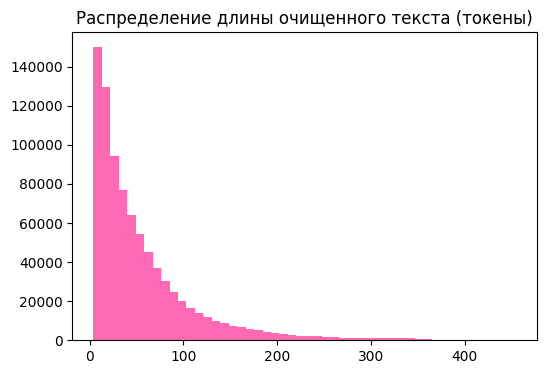

In [12]:
#распределение длины очищенного текста
lens = np.asarray([len(x.split()) for x in df["text_clean"]], dtype=np.int32)
plt.figure(figsize=(6, 4))
plt.hist(lens, bins=50, color="hotpink")
plt.title("Распределение длины очищенного текста (токены)")
plt.show()

## 3. BERTopic

In [13]:
#tuning-sample для bertopic
tune_n = min(TUNE_SAMPLE, len(df))
df_tune = df.sample(tune_n, random_state=SEED).reset_index(drop=True)
print(f"Tuning-sample: {tune_n:,} документов")

Tuning-sample: 15,000 документов


In [14]:
#вспомогательные функции bertopic
def _topic_diversity(topic_words, topk=10):
    w = [x for t in topic_words for x in t[:topk]]
    return (len(set(w)) / len(w)) if w else 0.0

def _bertopic_topic_words(model, topn=10):
    info = model.get_topic_info()
    topic_ids = [int(t) for t in info["Topic"].tolist() if int(t) != -1]
    return topic_ids, [[w for w, _ in (model.get_topic(t) or [])[:topn]] for t in topic_ids]

def _embedding_cache_path(embedder_key, n_docs=None):
    n_docs = len(docs) if n_docs is None else int(n_docs)
    return EMB_CACHE_DIR / f"embeddings_tune_{EMB_CACHE_TAG}_{embedder_key}_{n_docs}.npy"

def _embedding_chunk_cache_path(embedder_key, start, end, n_docs=None):
    n_docs = len(docs) if n_docs is None else int(n_docs)
    return EMB_CACHE_DIR / f"embeddings_tune_{EMB_CACHE_TAG}_{embedder_key}_{n_docs}_{start}_{end}.npy"

def _load_embedding_model(embedder_cfg):
    model = SentenceTransformer(
        embedder_cfg["model_name"],
        device=DEVICE,
        trust_remote_code=embedder_cfg.get("trust_remote_code", False),
    )
    model.max_seq_length = embedder_cfg.get("max_seq_length", 256)
    return model

def _iter_doc_bounds(n_docs, chunk_size):
    for start in range(0, n_docs, chunk_size):
        end = min(start + chunk_size, n_docs)
        yield start, end

def _encode_docs(embedder_key, embedder_cfg, docs):
    final_cache = _embedding_cache_path(embedder_key, len(docs))
    if final_cache.exists():
        print(f"Загружаем embeddings из кэша: {final_cache.name}")
        return np.load(final_cache)

    model = _load_embedding_model(embedder_cfg)
    encode_kwargs = {
        "show_progress_bar": True,
        "batch_size": embedder_cfg.get("batch_size", 64),
        **embedder_cfg.get("encode_kwargs", {}),
    }

    use_pool = False
    pool = None

    chunk_arrays = []
    try:
        bounds = list(_iter_doc_bounds(len(docs), EMBED_DOC_CHUNK))
        for i, (start, end) in enumerate(bounds, 1):
            chunk_cache = _embedding_chunk_cache_path(embedder_key, start, end, len(docs))
            if chunk_cache.exists():
                emb_chunk = np.load(chunk_cache)
                print(f"[{embedder_key}] chunk {i}/{len(bounds)} {start}:{end} -> cache")
            else:
                print(f"[{embedder_key}] chunk {i}/{len(bounds)} {start}:{end} -> encode")
                docs_chunk = docs[start:end]
                if use_pool:
                    emb_chunk = model.encode(docs_chunk, pool=pool, chunk_size=min(512, len(docs_chunk)), **encode_kwargs)
                else:
                    emb_chunk = model.encode(docs_chunk, **encode_kwargs)
                emb_chunk = np.asarray(emb_chunk)
                np.save(chunk_cache, emb_chunk)
            chunk_arrays.append(emb_chunk)

        emb = np.vstack(chunk_arrays) if chunk_arrays else np.empty((0, 0))
        np.save(final_cache, emb)
    finally:
        if pool is not None:
            model.stop_multi_process_pool(pool)
        del model
        gc.collect()
        pass

    return emb
    
#векторизатор для bertopic
def _build_vectorizer(fallback=False):
    return CountVectorizer(
        stop_words=list(vectorizer_stopwords),
        ngram_range=(1, 2),
        min_df=1 if fallback else 3,
        max_df=1.0 if fallback else 0.85,
        token_pattern=r"(?u)\b[а-яА-ЯёЁ][а-яА-ЯёЁ\-]{2,}\b",
    )

def _is_vectorizer_df_error(e):
    return "max_df corresponds to < documents than min_df" in str(e)

In [15]:
#данные и embeddings для bertopic
docs = [str(x) for x in df_tune["text_clean_bert"]]
docs_embed = [str(x) for x in df_tune["text_embed"]]
tokenized_bert = [x.split() for x in docs]

dictionary_bert = corpora.Dictionary(tokenized_bert)
dictionary_bert.filter_extremes(no_below=10, no_above=0.35)

print(f"BERTopic tune docs: {len(docs):,}")

embeddings_by_model = {}
for embedder_key, embedder_cfg in EMBEDDING_CANDIDATES.items():
    print(f"\n=== embeddings: {embedder_key} / {embedder_cfg['model_name']} ===")
    src_docs = docs_embed if embedder_key == "giga_instruct" else docs
    embeddings_by_model[embedder_key] = _encode_docs(embedder_key, embedder_cfg, src_docs)

BERTopic tune docs: 15,000

=== embeddings: rubert_sentence / DeepPavlov/rubert-base-cased-sentence ===
Загружаем embeddings из кэша: embeddings_tune_v2_giga_cluster_longctx_rubert_sentence_15000.npy

=== embeddings: giga_instruct / ai-sage/Giga-Embeddings-instruct ===
Загружаем embeddings из кэша: embeddings_tune_v2_giga_cluster_longctx_giga_instruct_15000.npy


In [16]:
#подбор bertopic по параметрам и эмбеддерам
param_grid = [
    {"n_neighbors": 10, "n_components": 5, "min_dist": 0.0, "min_cluster_size": 20},
    {"n_neighbors": 10, "n_components": 5, "min_dist": 0.0, "min_cluster_size": 30},
    {"n_neighbors": 10, "n_components": 8, "min_dist": 0.0, "min_cluster_size": 20},
    {"n_neighbors": 10, "n_components": 8, "min_dist": 0.0, "min_cluster_size": 30},
    {"n_neighbors": 15, "n_components": 5, "min_dist": 0.0, "min_cluster_size": 20},
    {"n_neighbors": 15, "n_components": 5, "min_dist": 0.0, "min_cluster_size": 30},
    {"n_neighbors": 15, "n_components": 8, "min_dist": 0.0, "min_cluster_size": 20},
    {"n_neighbors": 15, "n_components": 8, "min_dist": 0.0, "min_cluster_size": 30},
    {"n_neighbors": 20, "n_components": 5, "min_dist": 0.0, "min_cluster_size": 20},
    {"n_neighbors": 20, "n_components": 5, "min_dist": 0.0, "min_cluster_size": 30},
    {"n_neighbors": 20, "n_components": 8, "min_dist": 0.0, "min_cluster_size": 20},
    {"n_neighbors": 20, "n_components": 8, "min_dist": 0.0, "min_cluster_size": 30},
]

bert_runs = []
bert_labels = []
bert_coherences = []
bert_diversities = []
bert_n_topics = []

bert_best = None
bert_best_pack = None
best_bert_score = -1e9

for embedder_key, embedder_cfg in EMBEDDING_CANDIDATES.items():
    print(f"\n==================== {embedder_key} ====================")
    embedding_model = _load_embedding_model(embedder_cfg)
    embeddings = embeddings_by_model[embedder_key]

    for i, p in enumerate(param_grid, 1):
        print(f"\n--- BERTopic run {i}/{len(param_grid)} | {embedder_key}: nn={p['n_neighbors']}, nc={p['n_components']}, mcs={p['min_cluster_size']} ---")

        ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)
        representation_model = KeyBERTInspired(top_n_words=10)

        umap_model = UMAP(
            n_neighbors=p["n_neighbors"],
            n_components=p["n_components"],
            min_dist=p["min_dist"],
            metric="cosine",
            random_state=SEED,
            transform_seed=SEED,
        )

        hdbscan_model = hdbscan.HDBSCAN(
            min_cluster_size=p["min_cluster_size"],
            min_samples=max(10, p["min_cluster_size"] // 2),
            metric="euclidean",
            cluster_selection_method="eom",
            prediction_data=True,
        )

        vectorizer_fallback_used = False

        try:
            tm = BERTopic(
                embedding_model=embedding_model,
                vectorizer_model=_build_vectorizer(fallback=False),
                ctfidf_model=ctfidf_model,
                representation_model=representation_model,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                calculate_probabilities=False,
                low_memory=True,
                verbose=False,
            )
            topics, _ = tm.fit_transform(docs, embeddings=embeddings)

        except ValueError as e:
            if not _is_vectorizer_df_error(e):
                raise

            print("  fallback vectorizer: min_df=1, max_df=1.0")
            vectorizer_fallback_used = True

            tm = BERTopic(
                embedding_model=embedding_model,
                vectorizer_model=_build_vectorizer(fallback=True),
                ctfidf_model=ctfidf_model,
                representation_model=representation_model,
                umap_model=umap_model,
                hdbscan_model=hdbscan_model,
                calculate_probabilities=False,
                low_memory=True,
                verbose=False,
            )
            topics, _ = tm.fit_transform(docs, embeddings=embeddings)

        topic_info = tm.get_topic_info()
        topic_ids_real = [int(t) for t in topic_info["Topic"].tolist() if int(t) != -1]
        n_topics_real = len(topic_ids_real)

        topic_ids, topic_words = _bertopic_topic_words(tm, topn=10)
        vocab = set(dictionary_bert.token2id.keys())
        topic_words_clean, topic_ids_clean = [], []

        for tid, words in zip(topic_ids, topic_words):
            words_ok = [w for w in words if isinstance(w, str) and w in vocab and w not in topic_noise_stop and len(w) > 2]
            if len(words_ok) >= 2:
                topic_ids_clean.append(tid)
                topic_words_clean.append(words_ok)

        cm = None
        if topic_words_clean:
            cm = CoherenceModel(
                topics=topic_words_clean,
                texts=tokenized_bert,
                dictionary=dictionary_bert,
                coherence="c_v",
                processes=1,
            )
            coh = float(cm.get_coherence())
        else:
            coh = np.nan

        div = float(_topic_diversity(topic_words_clean, topk=10)) if topic_words_clean else np.nan
        n_topics_eval = len(topic_ids_clean)

        if pd.isna(coh) or pd.isna(div) or not (50 <= n_topics_real <= 150):
            score = -1e9
        else:
            score = coh + 0.05 * div

        print(
            f"  real n_topics={n_topics_real}, evaluable n_topics={n_topics_eval}, "
            f"coherence={coh:.4f}, diversity={div:.4f}, score={score:.4f}, "
            f"fallback={vectorizer_fallback_used}"
        )

        label = f"{embedder_key}|nn={p['n_neighbors']},nc={p['n_components']},mcs={p['min_cluster_size']}"
        bert_labels.append(label)
        bert_coherences.append(coh)
        bert_diversities.append(div)
        bert_n_topics.append(n_topics_real)

        bert_runs.append({
            "embedder_key": embedder_key,
            "embedder_model": embedder_cfg["model_name"],
            **p,
            "n_topics_real": n_topics_real,
            "n_topics_eval": n_topics_eval,
            "coherence_c_v": coh,
            "topic_diversity@10": div,
            "score": score,
            "vectorizer_fallback": vectorizer_fallback_used,
        })

        if score > best_bert_score:
            best_bert_score = score
            bert_best = tm
            bert_best_pack = {
                "embedder_key": embedder_key,
                "embedder_model": embedder_cfg["model_name"],
                "topics": topics,
                "topic_ids_real": topic_ids_real,
                "topic_ids_eval": topic_ids_clean,
                "topic_words_eval": topic_words_clean,
                "n_topics_real": n_topics_real,
                "n_topics_eval": n_topics_eval,
                "params": p,
                "coherence_c_v": coh,
                "topic_diversity@10": div,
                "score": score,
                "vectorizer_fallback": vectorizer_fallback_used,
            }
        else:
            del tm

        del topics, topic_ids, topic_words, topic_words_clean, topic_ids_clean, topic_info
        if cm is not None:
            del cm
        gc.collect()

    del embedding_model
    gc.collect()


bert_results_df = pd.DataFrame(bert_runs).sort_values(
    ["score", "coherence_c_v", "topic_diversity@10"],
    ascending=False,
).reset_index(drop=True)

bert_best_by_embedder_df = (
    bert_results_df.groupby("embedder_key", as_index=False)
    .first()
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

display(bert_best_by_embedder_df)
display(bert_results_df.head(20))


==================== rubert_sentence ====================


No sentence-transformers model found with name DeepPavlov/rubert-base-cased-sentence. Creating a new one with mean pooling.



--- BERTopic run 1/12 | rubert_sentence: nn=10, nc=5, mcs=20 ---
  real n_topics=90, evaluable n_topics=67, coherence=0.4323, diversity=0.9004, score=0.4774, fallback=False

--- BERTopic run 2/12 | rubert_sentence: nn=10, nc=5, mcs=30 ---
  real n_topics=3, evaluable n_topics=2, coherence=0.4280, diversity=0.5714, score=-1000000000.0000, fallback=False

--- BERTopic run 3/12 | rubert_sentence: nn=10, nc=8, mcs=20 ---
  real n_topics=94, evaluable n_topics=71, coherence=0.4244, diversity=0.8885, score=0.4688, fallback=False

--- BERTopic run 4/12 | rubert_sentence: nn=10, nc=8, mcs=30 ---
  fallback vectorizer: min_df=1, max_df=1.0
  real n_topics=3, evaluable n_topics=1, coherence=0.2977, diversity=1.0000, score=-1000000000.0000, fallback=True

--- BERTopic run 5/12 | rubert_sentence: nn=15, nc=5, mcs=20 ---
  real n_topics=79, evaluable n_topics=67, coherence=0.3932, diversity=0.8504, score=0.4357, fallback=False

--- BERTopic run 6/12 | rubert_sentence: nn=15, nc=5, mcs=30 ---
  fal

You are trying to use a model that was created with Sentence Transformers version 5.1.1, but you're currently using version 4.1.0. This might cause unexpected behavior or errors. In that case, try to update to the latest version.


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]


--- BERTopic run 1/12 | giga_instruct: nn=10, nc=5, mcs=20 ---
  real n_topics=169, evaluable n_topics=157, coherence=0.3674, diversity=0.7487, score=-1000000000.0000, fallback=False

--- BERTopic run 2/12 | giga_instruct: nn=10, nc=5, mcs=30 ---
  real n_topics=114, evaluable n_topics=112, coherence=0.3322, diversity=0.7957, score=0.3719, fallback=False

--- BERTopic run 3/12 | giga_instruct: nn=10, nc=8, mcs=20 ---
  real n_topics=167, evaluable n_topics=159, coherence=0.3490, diversity=0.7377, score=-1000000000.0000, fallback=False

--- BERTopic run 4/12 | giga_instruct: nn=10, nc=8, mcs=30 ---
  real n_topics=105, evaluable n_topics=103, coherence=0.3313, diversity=0.7575, score=0.3691, fallback=False

--- BERTopic run 5/12 | giga_instruct: nn=15, nc=5, mcs=20 ---
  real n_topics=155, evaluable n_topics=151, coherence=0.3565, diversity=0.7637, score=-1000000000.0000, fallback=False

--- BERTopic run 6/12 | giga_instruct: nn=15, nc=5, mcs=30 ---
  real n_topics=97, evaluable n_topi

,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
0,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,20,8,0.0,20,69,55,0.435279,0.875576,0.479058,False
1,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,5,0.0,20,145,141,0.363207,0.756164,0.401015,False


,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
0,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,20,8,0.0,20,69,55,0.435279,0.875576,4.790582e-01,False
1,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,10,5,0.0,20,90,67,0.432343,0.900383,4.773623e-01,False
2,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,10,8,0.0,20,94,71,0.424356,0.888489,4.687805e-01,False
3,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,20,5,0.0,20,73,57,0.398840,0.848101,4.412449e-01,False
4,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,15,5,0.0,20,79,67,0.393193,0.850365,4.357112e-01,False
5,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,5,0.0,20,145,141,0.363207,0.756164,4.010150e-01,False
6,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,5,0.0,30,97,97,0.357033,0.781250,3.960955e-01,False
7,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,8,0.0,30,103,100,0.350729,0.785586,3.900082e-01,False
8,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,8,0.0,30,94,93,0.349744,0.777164,3.886021e-01,False
9,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,8,0.0,20,149,143,0.350605,0.741633,3.876869e-01,False


In [17]:
#сохранение результатов bertopic tuning
BERT_RESULTS_XLSX = OUTPUT_DIR / "bert_results_df.xlsx"
BERT_RESULTS_CSV = OUTPUT_DIR / "bert_results_df.csv"
BERT_BEST_BY_EMBEDDER_XLSX = OUTPUT_DIR / "bert_best_by_embedder_df.xlsx"
BERT_BEST_BY_EMBEDDER_CSV = OUTPUT_DIR / "bert_best_by_embedder_df.csv"

bert_results_df.to_excel(BERT_RESULTS_XLSX, index=False)
bert_results_df.to_csv(BERT_RESULTS_CSV, index=False, encoding="utf-8-sig")

bert_best_by_embedder_df.to_excel(BERT_BEST_BY_EMBEDDER_XLSX, index=False)
bert_best_by_embedder_df.to_csv(BERT_BEST_BY_EMBEDDER_CSV, index=False, encoding="utf-8-sig")

print(BERT_RESULTS_XLSX)
print(BERT_RESULTS_CSV)
print(BERT_BEST_BY_EMBEDDER_XLSX)
print(BERT_BEST_BY_EMBEDDER_CSV)

results\bert_results_df.xlsx
results\bert_results_df.csv
results\bert_best_by_embedder_df.xlsx
results\bert_best_by_embedder_df.csv


In [18]:
#top-4 giga_instruct
bert_results_sorted = bert_results_df.sort_values(
    ["score", "coherence_c_v", "topic_diversity@10"],
    ascending=False
).reset_index(drop=True)

bert_top_giga = (
    bert_results_sorted.loc[bert_results_sorted["embedder_key"] == "giga_instruct"]
    .head(4)
    .reset_index(drop=True)
)

TOP_GIGA_XLSX = OUTPUT_DIR / "bert_top4_giga_instruct.xlsx"
TOP_GIGA_CSV = OUTPUT_DIR / "bert_top4_giga_instruct.csv"

bert_top_giga.to_excel(TOP_GIGA_XLSX, index=False)
bert_top_giga.to_csv(TOP_GIGA_CSV, index=False, encoding="utf-8-sig")

display(bert_top_giga)
print(TOP_GIGA_XLSX)
print(TOP_GIGA_CSV)

,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
0,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,5,0.0,20,145,141,0.363207,0.756164,0.401015,False
1,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,5,0.0,30,97,97,0.357033,0.781250,0.396096,False
2,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,8,0.0,30,103,100,0.350729,0.785586,0.390008,False
3,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,8,0.0,30,94,93,0.349744,0.777164,0.388602,False


results\bert_top4_giga_instruct.xlsx
results\bert_top4_giga_instruct.csv


## 4. Review лучших моделей

In [19]:
#review-модель bertopic
def build_bertopic_model_for_review(params, embedder_key, embeddings):
    docs_review = docs_embed if embedder_key == "giga_instruct" else docs

    umap_model = UMAP(
        n_neighbors=int(params["n_neighbors"]),
        n_components=int(params["n_components"]),
        min_dist=float(params["min_dist"]),
        metric="cosine",
        random_state=SEED,
        transform_seed=SEED,
    )

    hdbscan_model = hdbscan.HDBSCAN(
        min_cluster_size=int(params["min_cluster_size"]),
        min_samples=max(10, int(params["min_cluster_size"]) // 2),
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )

    try:
        model = BERTopic(
            embedding_model=None,
            vectorizer_model=_build_vectorizer(fallback=False),
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            top_n_words=15,
            calculate_probabilities=False,
            language="multilingual",
            verbose=False,
        )
        topics, _ = model.fit_transform(docs_review, embeddings)
    except ValueError as e:
        if "max_df corresponds to < documents than min_df" not in str(e):
            raise

        model = BERTopic(
            embedding_model=None,
            vectorizer_model=_build_vectorizer(fallback=True),
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            top_n_words=15,
            calculate_probabilities=False,
            language="multilingual",
            verbose=False,
        )
        topics, _ = model.fit_transform(docs_review, embeddings)

    return model, topics

In [21]:
#параметры из строки
def _params_from_row(row):
    return {
        "n_neighbors": int(row["n_neighbors"]),
        "n_components": int(row["n_components"]),
        "min_dist": float(row["min_dist"]),
        "min_cluster_size": int(row["min_cluster_size"]),
    }

In [26]:
#таблица топ-слов
def topic_words_table(model, topic_info, topn=12):
    rows = []

    for topic_id in topic_info["Topic"].tolist():
        if topic_id == -1:
            continue

        words = model.get_topic(topic_id)
        if words is None:
            continue

        top_words = [word for word, weight in words[:topn]]
        row = {
            "topic_id": topic_id,
            "count": int(topic_info.loc[topic_info["Topic"] == topic_id, "Count"].iloc[0]),
            "top_words": ", ".join(top_words),
        }

        for i, word in enumerate(top_words, start=1):
            row[f"word_{i}"] = word

        rows.append(row)

    return pd.DataFrame(rows)

In [29]:
#сохранение топиков
def save_topic_outputs(prefix, topic_info, topic_words_df):
    topic_info.to_csv(
        OUTPUT_DIR / f"{prefix}_topic_info.csv",
        index=False,
        encoding="utf-8-sig"
    )
    topic_words_df.to_csv(
        OUTPUT_DIR / f"{prefix}_top_words.csv",
        index=False,
        encoding="utf-8-sig"
    )

    topic_info.to_excel(
        OUTPUT_DIR / f"{prefix}_topic_info.xlsx",
        index=False
    )
    topic_words_df.to_excel(
        OUTPUT_DIR / f"{prefix}_top_words.xlsx",
        index=False
    )

    print("saved:", prefix)

In [30]:
#топ-слова лучшего rubert
rubert_best_row = (
    bert_results_df.loc[bert_results_df["embedder_key"] == "rubert_sentence"]
    .sort_values(["score", "coherence_c_v", "topic_diversity@10"], ascending=False)
    .iloc[0]
)

rubert_params = _params_from_row(rubert_best_row)
print("rubert_sentence best:")
display(rubert_best_row.to_frame().T)

tm_rubert, topics_rubert = build_bertopic_model_for_review(
    rubert_params,
    "rubert_sentence",
    embeddings_by_model["rubert_sentence"],
)

topic_info_rubert = tm_rubert.get_topic_info()
topic_words_rubert_df = topic_words_table(tm_rubert, topic_info_rubert, topn=12)

print("лучший rubert:")
print(f"n_topics_rubert: {int((topic_info_rubert['Topic'] != -1).sum())}")
display(topic_info_rubert.head(30))
display(topic_words_rubert_df)

save_topic_outputs("review_rubert_best", topic_info_rubert, topic_words_rubert_df)

del tm_rubert, topics_rubert
gc.collect()

rubert_sentence best:


,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
0,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,20,8,0.0,20,69,55,0.435279,0.875576,0.479058,False


лучший rubert:
n_topics_rubert: 69


,Topic,Count,Name,Representation,Representative_Docs
0,-1,8975,-1_украины_украине_заявил_трамп,"[украины, украине, заявил, трамп, трампа, росс...",[“девятый вал” накрывает украину: москве вменя...
1,0,1583,0_тыс_развития_первых_новых,"[тыс, развития, первых, новых, правительства, ...",[алексей оверчук: торгово-экономическое сотруд...
2,1,542,1_заявил_украины_нато_зеленский,"[заявил, украины, нато, зеленский, украине, ни...",[трамп: — у меня нет никаких заявлений для пут...
3,2,221,2_суд_колонии_делу_годам,"[суд, колонии, делу, годам, дела, свободы, дел...",[❗️ сотрудниками уфсб россии по хабаровскому к...
4,3,212,3_дронов_противника_операторы_группировки,"[дронов, противника, операторы, группировки, м...",[🎮 дроноводы бьют врага на всех направлениях 0...
5,4,198,4_переговоры_путин_встречи_президентом,"[переговоры, путин, встречи, президентом, разг...",[🇷🇺🇿🇦 состоялся телефонный разговор владимира ...
6,5,130,5_выборах_голосов_партии_выборы,"[выборах, голосов, партии, выборы, лдпр, прези...",[сегодня у нас традиционный социологический де...
7,6,129,6_израиль_израиля_ирана_израильские,"[израиль, израиля, ирана, израильские, израиль...",[начались четвертые сутки нового конфликта меж...
8,7,128,7_мошенники_банки_банков_мошенников,"[мошенники, банки, банков, мошенников, россиян...",[председатель правительства михаил мишустин по...
9,8,128,8_радио_смотрим_бывших_телеканале,"[радио, смотрим, бывших, телеканале, мардан, г...",[🔴🔴🔴🔴🔴начинаю свою трехчасовую программу «гасп...


,topic_id,count,top_words,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,word_10,word_11,word_12
0,0,1583,"тыс, развития, первых, новых, правительства, п...",тыс,развития,первых,новых,правительства,проект,проекта,рамках,экономики,новые,проектов,отметил
1,1,542,"заявил, украины, нато, зеленский, украине, ник...",заявил,украины,нато,зеленский,украине,никаких,россией,украина,трамп,гаспарян,путин,трампа
2,2,221,"суд, колонии, делу, годам, дела, свободы, дело...",суд,колонии,делу,годам,дела,свободы,дело,лишения,лишения свободы,уголовное,следствия,уголовное дело
3,3,212,"дронов, противника, операторы, группировки, ми...",дронов,противника,операторы,группировки,минобороны россии,дрон,войск,уничтожили,минобороны,направлении,группировки войск,дроноводы
4,4,198,"переговоры, путин, встречи, президентом, разго...",переговоры,путин,встречи,президентом,разговор,владимир,владимир путин,президент,зеленский,встречу,украины,обсудили
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,64,20,"соловьёв, подписывайся соловьёв, подписывайся,...",соловьёв,подписывайся соловьёв,подписывайся,соловьёв владимир,владимир путин,павла зарубина,владимир,зарубина,соловьёв соловьёв,ответы вопросы,путин,журналиста
65,65,20,"электроэнергии, аэс, линии электропередач, лин...",электроэнергии,аэс,линии электропередач,линии,электропередач,аварии,станции,курской,аварийных,владимирович,возникнуть,посмотрели
66,66,20,"круг, передка, погибли, радиус, ударила, небен...",круг,передка,погибли,радиус,ударила,небензя,топливо,австрии,урана,атакам,войны,подводных кабелей
67,67,20,"рутьюб, одноклассники, яндекс, михеев, сергей ...",рутьюб,одноклассники,яндекс,михеев,сергей михеев,смотрим,комментировать,вконтакте,фонд,дзен,сергей,вести


saved: review_rubert_best


3331

In [31]:
#топ-слова лучших giga после редукции
bert_top_giga_review = bert_top_giga.head(REVIEW_TOP_GIGA).reset_index(drop=True)
display(bert_top_giga_review)

for review_idx, row in bert_top_giga_review.iterrows():
    giga_params = _params_from_row(row)

    print(f"\n=== giga_instruct review_idx={review_idx} ===")
    display(row.to_frame().T)

    if DO_REVIEW_R20:
        tm_base, topics_base = build_bertopic_model_for_review(
            giga_params,
            "giga_instruct",
            embeddings_by_model["giga_instruct"],
        )
        tm_r20 = tm_base.reduce_topics(docs, nr_topics=20)
        topic_info_r20 = tm_r20.get_topic_info()
        topic_words_r20_df = topic_words_table(tm_r20, topic_info_r20, topn=12)

        print("после редукции до 20:")
        print(f"n_topics_r20: {int((topic_info_r20['Topic'] != -1).sum())}")
        display(topic_info_r20)
        display(topic_words_r20_df)

        save_topic_outputs(f"review_giga_idx{review_idx}_r20", topic_info_r20, topic_words_r20_df)

        del tm_base, topics_base, tm_r20, topic_info_r20, topic_words_r20_df
        gc.collect()


    if DO_REVIEW_R15:
        tm_base, topics_base = build_bertopic_model_for_review(
            giga_params,
            "giga_instruct",
            embeddings_by_model["giga_instruct"],
        )
        tm_r15 = tm_base.reduce_topics(docs, nr_topics=15)
        topic_info_r15 = tm_r15.get_topic_info()
        topic_words_r15_df = topic_words_table(tm_r15, topic_info_r15, topn=12)

        print("после редукции до 15:")
        print(f"n_topics_r15: {int((topic_info_r15['Topic'] != -1).sum())}")
        display(topic_info_r15)
        display(topic_words_r15_df)

        save_topic_outputs(f"review_giga_idx{review_idx}_r15", topic_info_r15, topic_words_r15_df)

        del tm_base, topics_base, tm_r15, topic_info_r15, topic_words_r15_df
        gc.collect()

,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
0,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,5,0.0,20,145,141,0.363207,0.756164,0.401015,False
1,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,5,0.0,30,97,97,0.357033,0.781250,0.396096,False



=== giga_instruct review_idx=0 ===


,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
0,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,5,0.0,20,145,141,0.363207,0.756164,0.401015,False


после редукции до 20:
n_topics_r20: 19


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5360,-1_украины_украине_россия_трамп,"[украины, украине, россия, трамп, трампа, пути...",[😌🎡🌅🗾🚝 «зеленский ждет интервенцию». зеленский...
1,0,3625,0_украине_трамп_трампа_нато,"[украине, трамп, трампа, нато, украины, россия...",[📝заявления президента россии владимира путина...
2,1,1332,1_войск_противника_направлении_группировки,"[войск, противника, направлении, группировки, ...",[🎖🎖🎖 министерства обороны российской федерации...
3,2,874,2_пво_белгородской_курская_опасности,"[пво, белгородской, курская, опасности, отбой,...",[🎖🎖🎖🎖 в период с 20.00 мск до 22.50 мск дежурн...
4,3,758,3_община_мигрантов_русская община_русская,"[община, мигрантов, русская община, русская, с...",[из-за детского конфликта взрослые мигранты на...
5,4,672,4_тыс_рынок_роста_компании,"[тыс, рынок, роста, компании, развития, эконом...",[инвестиционная активность в россии сталкивает...
6,5,439,5_гаспарян_русский_фильм_русский формат,"[гаспарян, русский, фильм, русский формат, фор...","[новый выпуск передачи закладка, известной так..."
7,6,351,6_нефти_газа_активов_пошлины,"[нефти, газа, активов, пошлины, брикс, нефть, ...","[европа, несмотря на санкционное давление, про..."
8,7,323,7_интеллекта_искусственного интеллекта_искусст...,"[интеллекта, искусственного интеллекта, искусс...",[киберструктуры пентагона и аффилированные с н...
9,8,312,8_община_русской_русская община_русская,"[община, русской, русская община, русская, сем...",[вместе мы – сила! 🇷🇺 руславка: официальный ма...


...

,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
1,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,5,0.0,30,97,97,0.357033,0.78125,0.396096,False


после редукции до 20:
n_topics_r20: 19


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5181,-1_украины_украине_россия_путин,"[украины, украине, россия, путин, трампа, трам...","[пол крейг робертс: трамп, может, и хотел бы р..."
1,0,4014,0_трамп_трампа_украине_президента,"[трамп, трампа, украине, президента, нато, укр...",[интересное за сегодня: – партии макрона и шол...
2,1,1045,1_войск_противника_группировки_группировки войск,"[войск, противника, группировки, группировки в...",[🎖🎖🎖 министерства обороны российской федерации...
3,2,821,2_экономики_цен_газа_нефти,"[экономики, цен, газа, нефти, российских, акти...",[инвестиционная активность в россии сталкивает...
4,3,759,3_община_русская община_русская_дело,"[община, русская община, русская, дело, суд, о...",[дружина русской общины ставрополя совместно с...
5,4,501,4_пво_атаки_белгородской_средствами пво,"[пво, атаки, белгородской, средствами пво, мин...",[⚡️ около 18.45 мск пресечена попытка киевског...
6,5,445,5_компании_доступ_искусственного интеллекта_ин...,"[компании, доступ, искусственного интеллекта, ...",[российские власти продолжают методично выстра...
7,6,378,6_гаспарян_фильм_песни_искусств,"[гаспарян, фильм, песни, искусств, телеканале,...","[новый выпуск передачи закладка, известной так..."
8,7,338,7_тыс_проект_развития_строительства,"[тыс, проект, развития, строительства, новых, ...","[встретился с дорогим братом, первым заместите..."
9,8,291,8_закон_семьи_церкви_храма,"[закон, семьи, церкви, храма, церковь, женщин,...",[💬 официальный таллин продолжает усиливать дав...


,topic_id,count,top_words,word_1,word_2,word_3,word_4,word_5,word_6,word_7,word_8,word_9,word_10,word_11,word_12
0,0,4014,"трамп, трампа, украине, президента, нато, укра...",трамп,трампа,украине,президента,нато,украины,россия,президент,путин,путина,израиля,зеленский
1,1,1045,"войск, противника, группировки, группировки во...",войск,противника,группировки,группировки войск,бригады,направлении,бригад,военнослужащих,поражение,противник,бои,пунктов
2,2,821,"экономики, цен, газа, нефти, российских, актив...",экономики,цен,газа,нефти,российских,активов,развития,компании,цены,роста,рынка,тыс
3,3,759,"община, русская община, русская, дело, суд, об...",община,русская община,русская,дело,суд,общины,фсб,дела,русской общины,русской,уголовное,уголовное дело
4,4,501,"пво, атаки, белгородской, средствами пво, мино...",пво,атаки,белгородской,средствами пво,минобороны,средствами,самолетного типа,самолетного,мск,типа,пострадавших,селе
5,5,445,"компании, доступ, искусственного интеллекта, и...",компании,доступ,искусственного интеллекта,интеллекта,искусственного,связи,данных,мошенники,россиян,мошенников,безопасности,деньги
6,6,378,"гаспарян, фильм, песни, искусств, телеканале, ...",гаспарян,фильм,песни,искусств,телеканале,культуры,россия,фио,программу,книги,книга,искусства
7,7,338,"тыс, проект, развития, строительства, новых, и...",тыс,проект,развития,строительства,новых,инфраструктуры,дороги,ограничения,строительство,метро,транспорта,жкх
8,8,291,"закон, семьи, церкви, храма, церковь, женщин, ...",закон,семьи,церкви,храма,церковь,женщин,ценности,нашей,женщины,русской,православной,беременности
9,9,266,"дронов, противника, группировки, войск, минобо...",дронов,противника,группировки,войск,минобороны россии,дрон,минобороны,операторы,группировки войск,направлении,дроны,танк


saved: review_giga_idx1_r20


По итогам ручного просмотра двух лучших конфигураций с Giga embeddings наиболее удачным вариантом выглядит модель idx1 (n_neighbors=15, n_components=5, min_cluster_size=30), а не idx0.

Во-первых, исходная модель idx1 получается более компактной: она выделяет 97 тем до редукции, тогда как idx0 выделяет 145 тем. При этом итоговый score у них очень близкий: 0.396 против 0.401. То есть формально idx0 немного выше по score, но разница небольшая.

Во-вторых, у idx1 выше topic diversity: 0.781 против 0.756. Это важно, потому что после редукции позволяет получить набор тем, которые меньше дублируют друг друга.

По содержанию idx1 тоже выглядит немного лучше, потому что после редукции до 20 тем у него более аккуратно отделяются крупные тематические блоки: международная политика / Украина / Трамп / НАТО, боевые действия, экономика и энергетика, миграция и русская община, ИИ, инфраструктура, религия и семья, спорт, здравоохранение, образование.

У idx0 темы тоже в целом содержательные, но после редукции заметнее кажутся мелкие и мало содержательные моменты вроде отдельных тем про «ахмат сила», «проводит тренировки» и т.д. У idx0 также сильнее дублируется блок про русскую общину.

Для дальнейшего анализа будем использовать следующую конфигурацию giga_instruct с параметрами n_neighbors=15, n_components=5, min_dist=0.0, min_cluster_size=30 и редукцией до 20 тем.

## 5. Диагностика

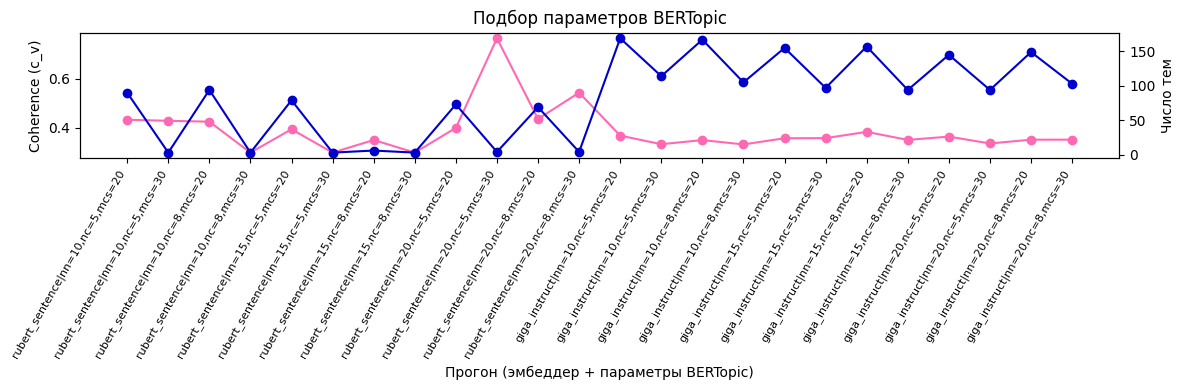

In [32]:
#графики bertopic
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(range(len(bert_labels)), bert_coherences, marker="o", color="hotpink")
ax1.set_xlabel("Прогон (эмбеддер + параметры BERTopic)")
ax1.set_ylabel("Coherence (c_v)")
ax1.set_xticks(range(len(bert_labels)))
ax1.set_xticklabels(bert_labels, rotation=60, ha="right", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(range(len(bert_labels)), bert_n_topics, marker="o", color="mediumblue")
ax2.set_ylabel("Число тем")

plt.title("Подбор параметров BERTopic")
plt.tight_layout()
plt.show()

In [33]:
#сводка bertopic
print("Лучшие BERTopic по эмбеддерам:")
display(bert_best_by_embedder_df[[
    "embedder_key",
    "embedder_model",
    "n_neighbors",
    "n_components",
    "min_cluster_size",
    "n_topics_real",
    "n_topics_eval",
    "coherence_c_v",
    "topic_diversity@10",
    "score",
]])

print("Top giga_instruct:")
display(bert_top_giga)

Лучшие BERTopic по эмбеддерам:


,embedder_key,embedder_model,n_neighbors,n_components,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score
0,rubert_sentence,DeepPavlov/rubert-base-cased-sentence,20,8,20,69,55,0.435279,0.875576,0.479058
1,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,5,20,145,141,0.363207,0.756164,0.401015


Top giga_instruct:


,embedder_key,embedder_model,n_neighbors,n_components,min_dist,min_cluster_size,n_topics_real,n_topics_eval,coherence_c_v,topic_diversity@10,score,vectorizer_fallback
0,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,5,0.0,20,145,141,0.363207,0.756164,0.401015,False
1,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,5,0.0,30,97,97,0.357033,0.781250,0.396096,False
2,giga_instruct,ai-sage/Giga-Embeddings-instruct,20,8,0.0,30,103,100,0.350729,0.785586,0.390008,False
3,giga_instruct,ai-sage/Giga-Embeddings-instruct,15,8,0.0,30,94,93,0.349744,0.777164,0.388602,False
